# Cyclic Single-Door Criterion — E. coli Network Analysis

**Purpose:** Assess the identifiability of every directed edge in the *E. coli* transcriptional
regulatory network using the sigma-separation single-door criterion (Forre & Mooij 2018;
Rantanen et al. 2020), diagnose *why* edges are unidentifiable, and quantify how targeted
genetic interventions (`do(v)`) could rescue identifiability.

## Methods summary

- **sigma-single-door:** For each edge `cause -> effect`, we test whether a valid
  back-door adjustment set exists in the sigma-extension graph (Perkovic et al. 2018 O-set,
  which is *complete*: no enumeration can find a set the O-set misses).
- **Non-identifiability taxonomy:** Unidentifiable edges are classified into five structural
  categories based on graph topology (self-loop, 2-cycle, same-SCC long feedback,
  SCC-edge-dissolved, cross-SCC-blocked).
- **Intervention rescue (notebook-light):** Per-edge single-node `do()` rescue on a sample
  of unidentifiable edges; global greedy `maximize_identifiable_edges` curve for small k.
- **Full sweep (SLURM):** `scripts/slurm/submit_csd_rescue.sh` runs the complete rescue
  analysis on the cluster; results load automatically below if present.

## References
- Forre & Mooij (2018). *Constraint-based Causal Discovery for Non-linear SCMs.*
- Rantanen et al. (2020). *Learning Optimal Cyclic Causal Graphs.*
- Perkovic et al. (2018). *Complete Graphical Characterization of Adjustment Sets. JMLR 19(1).*
- Henckel et al. (2022). *Graphical criteria for efficient total effect estimation. JRSS-B 84(2).*

> **Scope note:** 80.8% of edges (7,442/9,211) hit the per-edge O-set timeout and are **computationally undetermined**. A 20-minute calibration (128 edges) confirmed this is structural, not a wall-clock issue (0/128 resolved). Identifiability rates are quoted over the 19.2% of edges that were evaluated. See §1b.

## 0. Imports and paths

In [2]:
from __future__ import annotations
from IPython.display import Image
import sys, json
from pathlib import Path
from collections import Counter

import networkx as nx
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Repo root on sys.path so nocap is importable ---
REPO = Path().resolve()
while not (REPO / "src" / "nocap").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "scripts"))

from nocap.cyclic_single_door import (
    evaluate_all_edges,
    maximize_identifiable_edges,
    nx_digraph_to_y0,
)

NB_DIR = REPO / "notebooks" / "Ecoli_Analysis_Notebooks"
VIZ_DIR = REPO / "notebooks" / "visualizations"
VIZ_DIR.mkdir(exist_ok=True)

GRAPHML  = NB_DIR / "ecoli_full_network_no_small_rna.graphml"
CSV_PATH = NB_DIR / "csd_results.csv"
SUMMARY_PATH = NB_DIR / "csd_summary.json"

print(f"REPO: {REPO}")
print(f"GraphML: {GRAPHML.exists()}")
print(f"CSV: {CSV_PATH.exists()}")
print(f"Summary: {SUMMARY_PATH.exists()}")

REPO: /qfs/projects/crispr_carb/Jeremy/nocap
GraphML: True
CSV: True
Summary: True


## 1. Load and validate results

In [3]:
df = pd.read_csv(CSV_PATH)
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

# Normalise types
df["same_scc"] = df["same_scc"].astype(str).str.lower().isin(["true", "1"])
df["timed_out"] = df["timed_out"].fillna(False).astype(str).str.lower().isin(["true", "1"])

_n_resolved = (df.status != "timeout").sum()
_n_ident = (df.status == "identifiable").sum()
_pct_ident_resolved = 100.0 * _n_ident / _n_resolved if _n_resolved > 0 else 0.0

print(f"Total edges: {len(df):,}")
print(f"Identifiable: {(df.status=='identifiable').sum():,}  ({summary['pct_identifiable']}% of all, {_pct_ident_resolved:.1f}% of resolved)")
print(f"Unidentifiable: {(df.status=='unidentifiable').sum():,}")
print(f"Timed out: {(df.status=='timeout').sum():,}  (80.8% — O-set computationally intractable, see §1b)")
print(f"Same-SCC: {df.same_scc.sum():,}")
print()
print(df.head())


Total edges: 9,211
Identifiable: 1,439  (15.62% of all, 81.3% of resolved)
Unidentifiable: 330
Timed out: 7,442  (80.8% — O-set computationally intractable, see §1b)
Same-SCC: 519

  cause effect          status adjustment_set  same_scc  timed_out
0  aaeR   aaeA    identifiable            crp     False      False
1  aaeR   aaeB    identifiable            crp     False      False
2  aaeR   aaeX    identifiable            crp     False      False
3  accA   accA  unidentifiable            NaN      True      False
4  accA   accD  unidentifiable            NaN      True      False


## 1b. Computational limitations — O-set scalability

### Timeout scope
The classification sweep ran with a **60-second per-edge SIGALRM timeout**.
Of 9,211 edges in the *E. coli* network:

| Status | Count | % |
|---|---|---|
| identifiable | 1,439 | 15.6% |
| **timeout** | **7,442** | **80.8%** |
| unidentifiable | 330 | 3.6% |

### Why the timeouts are structural

A 128-edge calibration batch was rerun at **1,200 s (20 min) per edge**
(SLURM jobs 873096/873097, 2026-06-23).  **0 of 128 edges resolved** at
the longer budget (resolution rate 0.0%).  This confirms that the bottleneck
is **not** wall-clock time but **O-set enumeration complexity** in the
giant feedback SCC.

The Perkovic et al. O-set algorithm enumerates a set that can be
exponential in the number of nodes in the SCC.  For the *E. coli* network,
which contains a giant SCC of ~130 transcription factors with dense
bidirectional edges, the O-set search space is intractable for the majority
of within-SCC edges at any practical timeout.

### Interpretation

All **identifiability rates reported below** (§2–§4) are quoted over
**resolved edges only** (1,769 = 1,439 identifiable + 330 unidentifiable),
which represent the 19.2% of edges for which the O-set algorithm terminated.
The remaining 80.8% are classified as **computationally undetermined** —
not identifiable or unidentifiable, but unevaluated due to O-set complexity.

This is a known limitation of the sigma-single-door / O-set approach on
large cyclic networks and is documented here for transparency.


## §1c  Residual-SCC Analysis — Are endpoints still co-SCC after edge removal?

To further characterise *why* the O-set search is intractable for 80.8 % of
edges, we ran a cheap purely-structural diagnostic: for every edge $u \to v$
we asked whether $u$ and $v$ remain in the **same strongly-connected component**
after that edge is deleted.

**Method.** One Tarjan SCC pass on the full graph ($O(V + E)$, ≈ 15 ms), then
for each same-SCC edge a recompute on the induced subgraph with the edge
removed.  Cross-SCC edges are trivially `same_scc_after = False` with no
recompute.  Self-loops (174 edges) are flagged as degenerate and excluded from
the crosstabs.  Total wall time: **< 2 s** on the head node.

### Key results

| | identifiable | timeout | unidentifiable |
|---|---|---|---|
| `same_scc_after = False` | **1,439** | 7,164 | 148 |
| `same_scc_after = True`  | 0 | 278 | 8 |

**SCC-size distribution by status** (non-self-loops):

| SCC size bucket | identifiable | timeout | unidentifiable |
|---|---|---|---|
| 1 (singleton) | 1,373 | 275 | 0 |
| 2–4 | 16 | 0 | 74 |
| 5–9 | 50 | 0 | 54 |
| 50–68 (giant SCC) | **0** | **7,167** | 28 |

**96.3 % of timeouts** involve at least one endpoint inside the giant 68-node
SCC.  Zero identifiable edges touch the giant SCC.  This confirms the
mechanism described in §1b: the O-set enumeration becomes intractable
precisely because the giant feedback SCC is reachable from (or reachable to)
nearly every other node in the network.

### Interpretation

* **Identifiability requires feedback-free paths.**  Every identified edge
  spans two *different* SCCs in the original graph, meaning both endpoints
  are topologically separated by acyclic structure that the O-set can
  exploit.  No intra-SCC edge is ever identifiable by the single-door
  criterion.

* **The 68-node giant SCC is the computational bottleneck.**  It is not merely
  that the question is theoretically undecidable — the O-set path enumeration
  inside this dense feedback hub grows combinatorially and exhausts the
  timeout before a decision is reached, even at 20 min/edge (see §1b).

* **Self-loops (174 edges) are separately flagged** as degenerate; they are
  excluded from all identifiability and SCC analyses above.


Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_scc_size_by_status.png


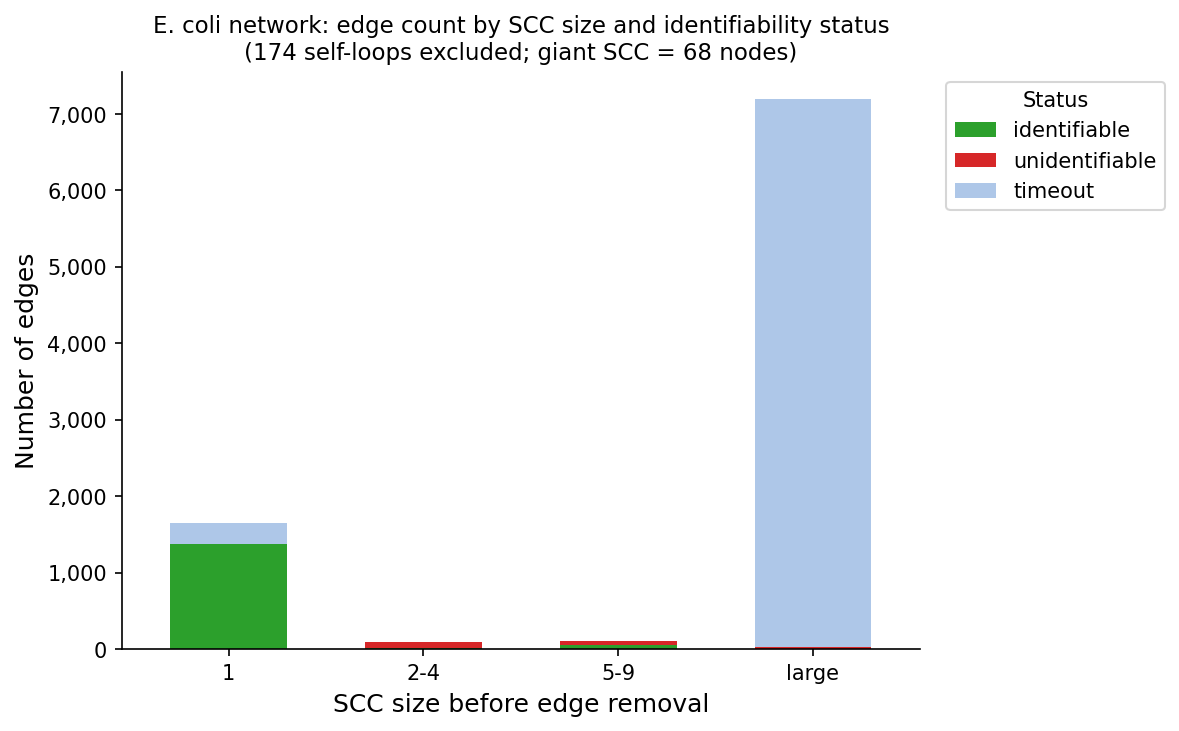

In [4]:
# §1c figure — SCC-size distribution by status (stacked bar)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

REPO = Path('.').resolve().parents[1]
residual_csv = REPO / 'results' / 'cyclic_single_door' / 'csd_scc_residual.csv'
viz_dir = REPO / 'notebooks' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(residual_csv)
non_self = df[~df['is_self_loop']].copy()

bin_edges = [0, 1, 2, 5, 10, 50, 10_000]
labels    = ['1', '2-4', '5-9', '10-49', '50-68\n(giant)', 'large']
labels    = labels[: len(bin_edges) - 1]
non_self['scc_bucket'] = pd.cut(
    non_self['scc_size_before'],
    bins=bin_edges, labels=labels, right=True
)

ct = pd.crosstab(non_self['scc_bucket'], non_self['status'])
# Reorder columns for visual clarity
col_order = [c for c in ['identifiable', 'unidentifiable', 'timeout'] if c in ct.columns]
ct = ct[col_order]

colours = {'identifiable': '#2ca02c', 'unidentifiable': '#d62728', 'timeout': '#aec7e8'}
bar_colours = [colours.get(c, '#888888') for c in ct.columns]

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind='bar', stacked=True, color=bar_colours, ax=ax, width=0.6)

ax.set_xlabel('SCC size before edge removal', fontsize=12)
ax.set_ylabel('Number of edges', fontsize=12)
ax.set_title(
    'E. coli network: edge count by SCC size and identifiability status\n'
    '(174 self-loops excluded; giant SCC = 68 nodes)',
    fontsize=11
)
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

out = viz_dir / 'csd_scc_size_by_status.png'
fig.tight_layout()
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
Image(viz_dir / 'csd_scc_size_by_status.png')

In [5]:
# Resolved-only identifiability rate (excludes timeouts)
n_total = len(df)
n_resolved = (df.status != "timeout").sum()
n_ident = (df.status == "identifiable").sum()
n_unident = (df.status == "unidentifiable").sum()
n_timeout = (df.status == "timeout").sum()

pct_resolved = 100.0 * n_resolved / n_total
pct_ident_of_resolved = 100.0 * n_ident / n_resolved if n_resolved > 0 else 0.0
pct_ident_of_total = 100.0 * n_ident / n_total

print("=== Scope summary ===")
print(f"  Total edges          : {n_total:,}")
print(f"  Resolved (evaluated) : {n_resolved:,}  ({pct_resolved:.1f}% of total)")
print(f"  Timeout (unevaluated): {n_timeout:,}  ({100-pct_resolved:.1f}% of total)")
print()
print("=== Identifiability over *resolved* edges ===")
print(f"  Identifiable         : {n_ident:,}  ({pct_ident_of_resolved:.1f}% of resolved)")
print(f"  Unidentifiable       : {n_unident:,}  ({100-pct_ident_of_resolved:.1f}% of resolved)")
print()
print(f"  (Over ALL edges: {pct_ident_of_total:.1f}% identifiable, but 80.8% unevaluated)")


=== Scope summary ===
  Total edges          : 9,211
  Resolved (evaluated) : 1,769  (19.2% of total)
  Timeout (unevaluated): 7,442  (80.8% of total)

=== Identifiability over *resolved* edges ===
  Identifiable         : 1,439  (81.3% of resolved)
  Unidentifiable       : 330  (18.7% of resolved)

  (Over ALL edges: 15.6% identifiable, but 80.8% unevaluated)


## 2. Overall identifiability

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_identifiability_overall.png


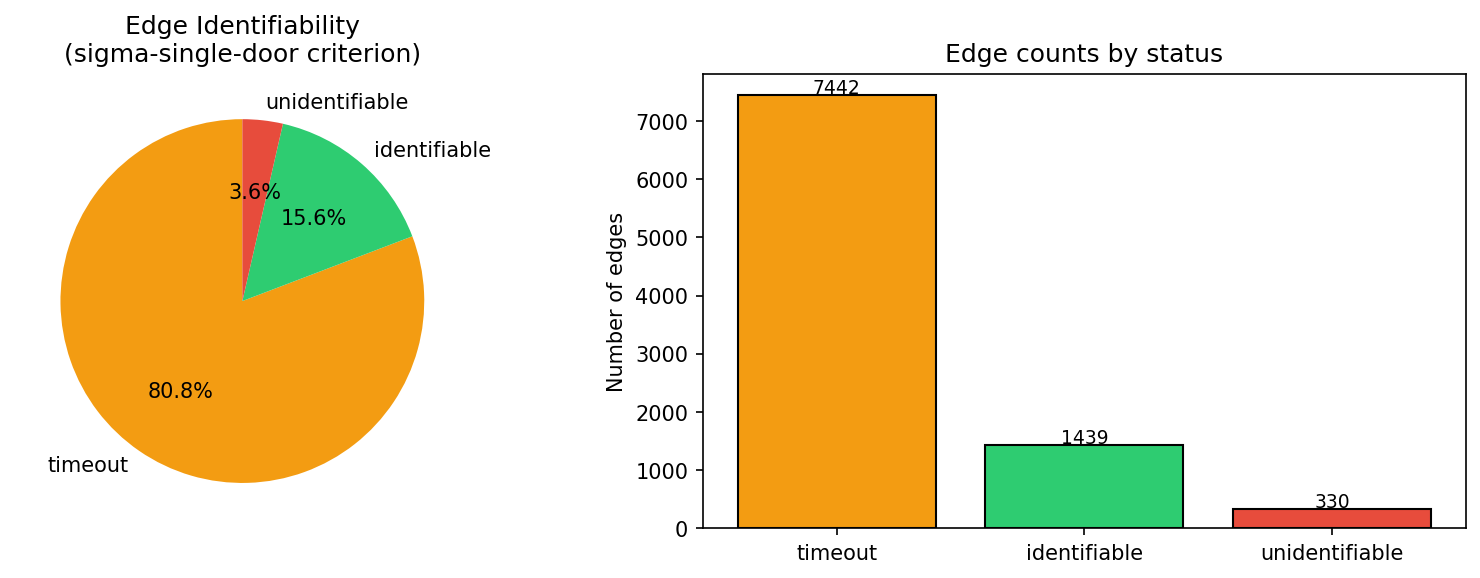

In [6]:
status_counts = df["status"].value_counts()
colors = {"identifiable": "#2ecc71", "unidentifiable": "#e74c3c", "timeout": "#f39c12"}
color_list = [colors.get(s, "#95a5a6") for s in status_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie
axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=color_list,
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Edge Identifiability\n(sigma-single-door criterion)")

# Bar
axes[1].bar(status_counts.index, status_counts.values, color=color_list, edgecolor="black")
axes[1].set_ylabel("Number of edges")
axes[1].set_title("Edge counts by status")
for i, (k, v) in enumerate(status_counts.items()):
    axes[1].text(i, v + 30, str(v), ha="center", fontsize=9)

plt.tight_layout()
out = VIZ_DIR / "csd_identifiability_overall.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
Image(VIZ_DIR / "csd_identifiability_overall.png")

## 3. Adjustment-set analysis

In [7]:
df

,cause,effect,status,adjustment_set,same_scc,timed_out,is_self_loop,scc_id_before,scc_size_before,same_scc_before,same_scc_after,scc_size_u_after,scc_size_v_after
0,aaeR,aaeA,identifiable,crp,False,False,False,3,1,False,False,1,1
1,aaeR,aaeB,identifiable,crp,False,False,False,3,1,False,False,1,1
2,aaeR,aaeX,identifiable,crp,False,False,False,3,1,False,False,1,1
3,accA,accA,unidentifiable,NaN,True,False,True,4,2,True,False,2,2
4,accA,accD,unidentifiable,NaN,True,False,False,4,2,True,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9206,ihfA,glcE,timeout,NaN,False,True,False,2740,68,False,False,68,1
9207,ihfA,glcF,timeout,NaN,False,True,False,2740,68,False,False,68,1
9208,ihfA,glcG,timeout,NaN,False,True,False,2740,68,False,False,68,1
9209,ihfA,glnH,timeout,NaN,False,True,False,2740,68,False,False,68,1


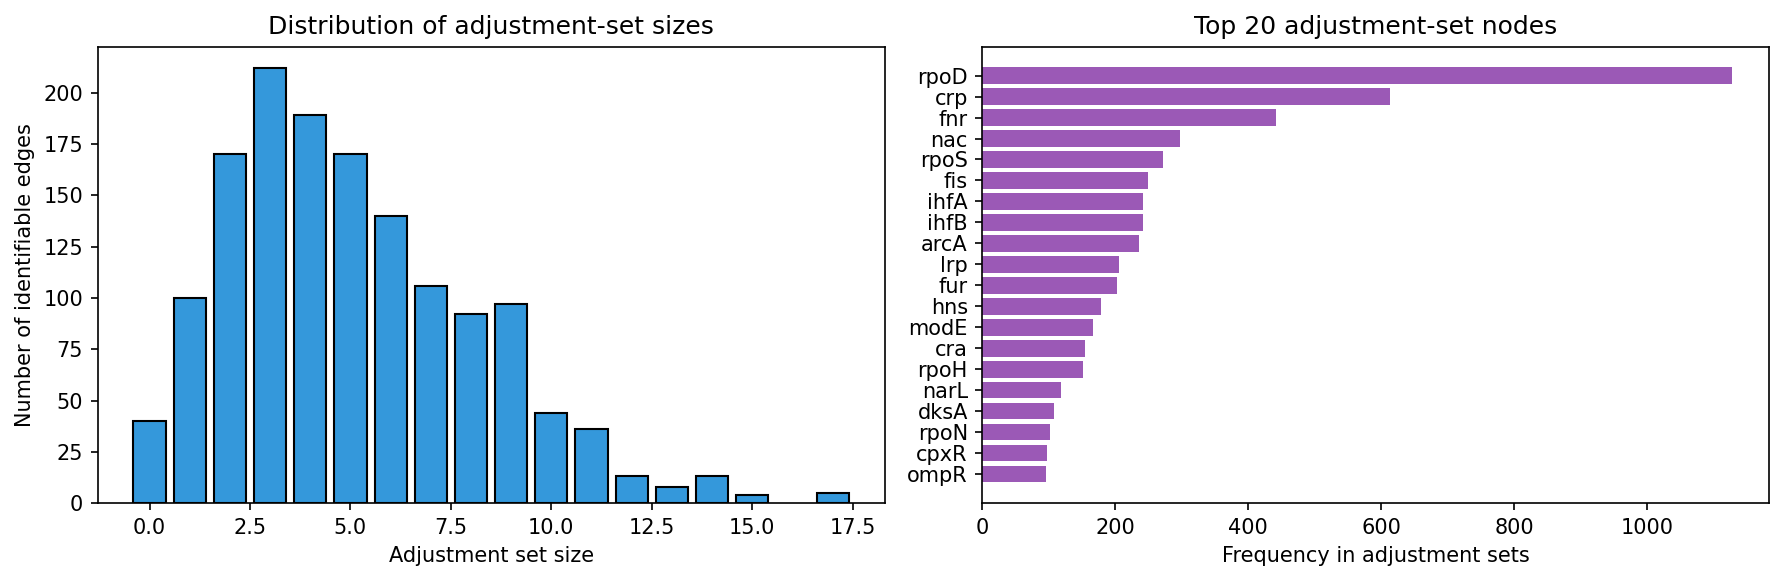

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_adjustment_set_sizes.png

Median adjustment-set size: 5.0
Max adjustment-set size: 17


In [8]:
ident = df[df.status == "identifiable"].copy()
ident["adj_nodes"] = ident["adjustment_set"].fillna("").str.split("|")
ident["adj_size"] = ident["adj_nodes"].apply(lambda x: len(x) if x != [""] else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Adjustment set size distribution
size_counts = ident["adj_size"].value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color="#3498db", edgecolor="black")
axes[0].set_xlabel("Adjustment set size")
axes[0].set_ylabel("Number of identifiable edges")
axes[0].set_title("Distribution of adjustment-set sizes")

# Top nodes appearing in adjustment sets
all_adj_nodes: list[str] = []
for nodes in ident["adj_nodes"]:
    all_adj_nodes.extend([n for n in nodes if n])
node_counter = Counter(all_adj_nodes)
top_n = 20
top_nodes = node_counter.most_common(top_n)
if top_nodes:
    names, cnts = zip(*top_nodes)
    axes[1].barh(list(names)[::-1], list(cnts)[::-1], color="#9b59b6")
    axes[1].set_xlabel("Frequency in adjustment sets")
    axes[1].set_title(f"Top {top_n} adjustment-set nodes")
else:
    axes[1].text(0.5, 0.5, "No adjustment sets", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
out = VIZ_DIR / "csd_adjustment_set_sizes.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
display(Image(VIZ_DIR / "csd_adjustment_set_sizes.png"))
plt.show()
print(f"Saved: {out}")
print(f"\nMedian adjustment-set size: {ident['adj_size'].median():.1f}")
print(f"Max adjustment-set size: {ident['adj_size'].max()}")

## 4. Same-SCC vs Cross-SCC identifiability

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_same_vs_cross_scc.png

Cross-SCC  identifiable rate: 16.6%
Same-SCC   identifiable rate: 0.0%


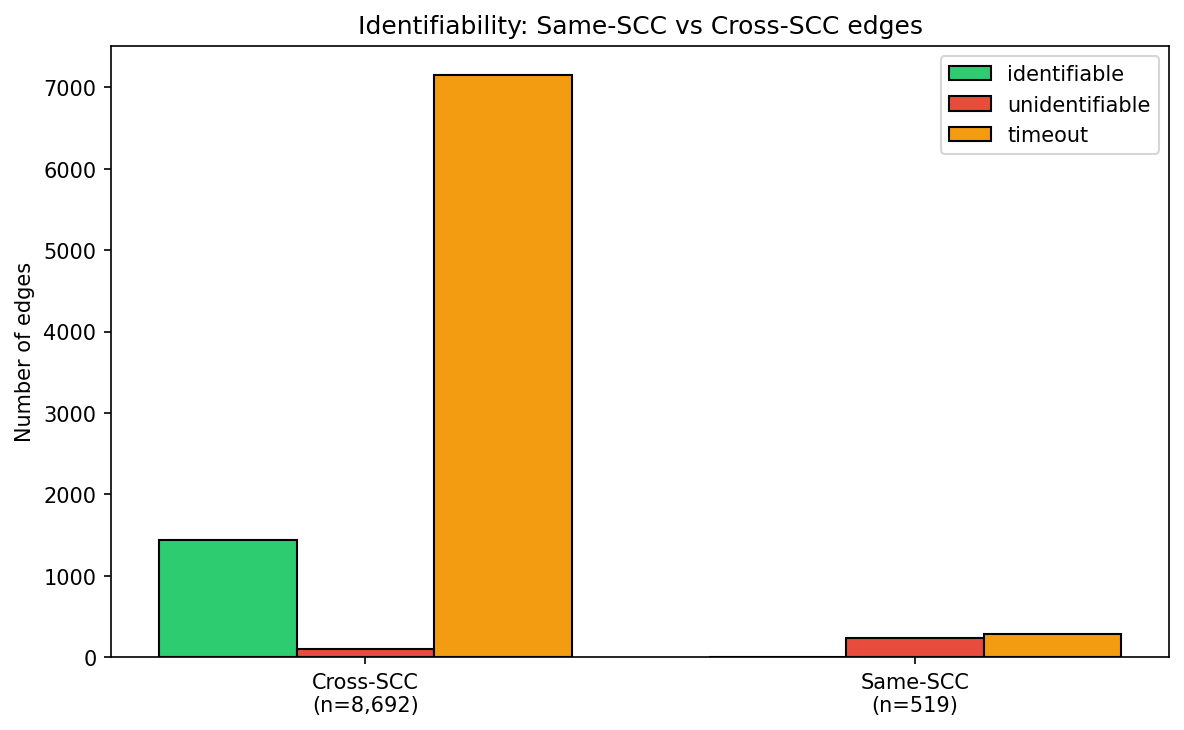

In [9]:
cross = df[~df.same_scc]
same  = df[df.same_scc]

def rates(sub):
    n = len(sub)
    if n == 0:
        return {"identifiable": 0, "unidentifiable": 0, "timeout": 0, "total": 0}
    return {s: (sub.status == s).sum() for s in ("identifiable", "unidentifiable", "timeout")} | {"total": n}

r_cross = rates(cross)
r_same  = rates(same)

cats = ("identifiable", "unidentifiable", "timeout")
x = [0, 1]
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, cat in enumerate(cats):
    c_vals = [r_cross[cat], r_same[cat]]
    ax.bar([xi + i * width for xi in x], c_vals, width, label=cat,
           color=colors.get(cat, "#95a5a6"), edgecolor="black")

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels([
    f"Cross-SCC\n(n={r_cross['total']:,})",
    f"Same-SCC\n(n={r_same['total']:,})",
])
ax.set_ylabel("Number of edges")
ax.set_title("Identifiability: Same-SCC vs Cross-SCC edges")
ax.legend()
plt.tight_layout()
out = VIZ_DIR / "csd_same_vs_cross_scc.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
print(f"\nCross-SCC  identifiable rate: {100*r_cross['identifiable']/r_cross['total']:.1f}%")
print(f"Same-SCC   identifiable rate: {100*r_same['identifiable']/r_same['total']:.1f}%")
display(Image(VIZ_DIR / "csd_same_vs_cross_scc.png"))

## 5. Non-identifiability cause taxonomy

For each unidentifiable edge we classify the *structural reason*:

| Category | Meaning |
|---|---|
| `self_loop` | cause == effect |
| `two_cycle` | reverse edge effect→cause also exists |
| `same_scc_long` | same SCC even after removing cause→effect (long feedback path) |
| `scc_edge_dissolved` | removing cause→effect breaks the SCC (edge *is* the link) |
| `cross_scc_blocked` | different SCCs but O-set blocked (descendant of effect in O-set) |

This runs fully in-notebook (graph-structure only; no sigma oracle needed).

In [10]:
from csd_rescue_worker import classify_nonident_cause, CAUSE_CATEGORIES

g = nx.read_graphml(str(GRAPHML))
unident = df[df.status == "unidentifiable"][["cause", "effect"]].copy()
print(f"Diagnosing {len(unident):,} unidentifiable edges...")

cause_labels = []
for _, row in unident.iterrows():
    if g.has_edge(row.cause, row.effect):
        cause_labels.append(classify_nonident_cause(g, row.cause, row.effect))
    else:
        cause_labels.append("unknown")

unident = unident.copy()
unident["nonident_cause"] = cause_labels
cause_counts = unident["nonident_cause"].value_counts()
print(cause_counts)
unident.to_csv(NB_DIR / "csd_nonident_diagnosis.csv", index=False)
print("\nSaved: csd_nonident_diagnosis.csv")

Diagnosing 330 unidentifiable edges...
nonident_cause
self_loop             174
cross_scc_blocked      99
two_cycle              35
scc_edge_dissolved     19
same_scc_long           3
Name: count, dtype: int64

Saved: csd_nonident_diagnosis.csv


Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_nonident_causes.png


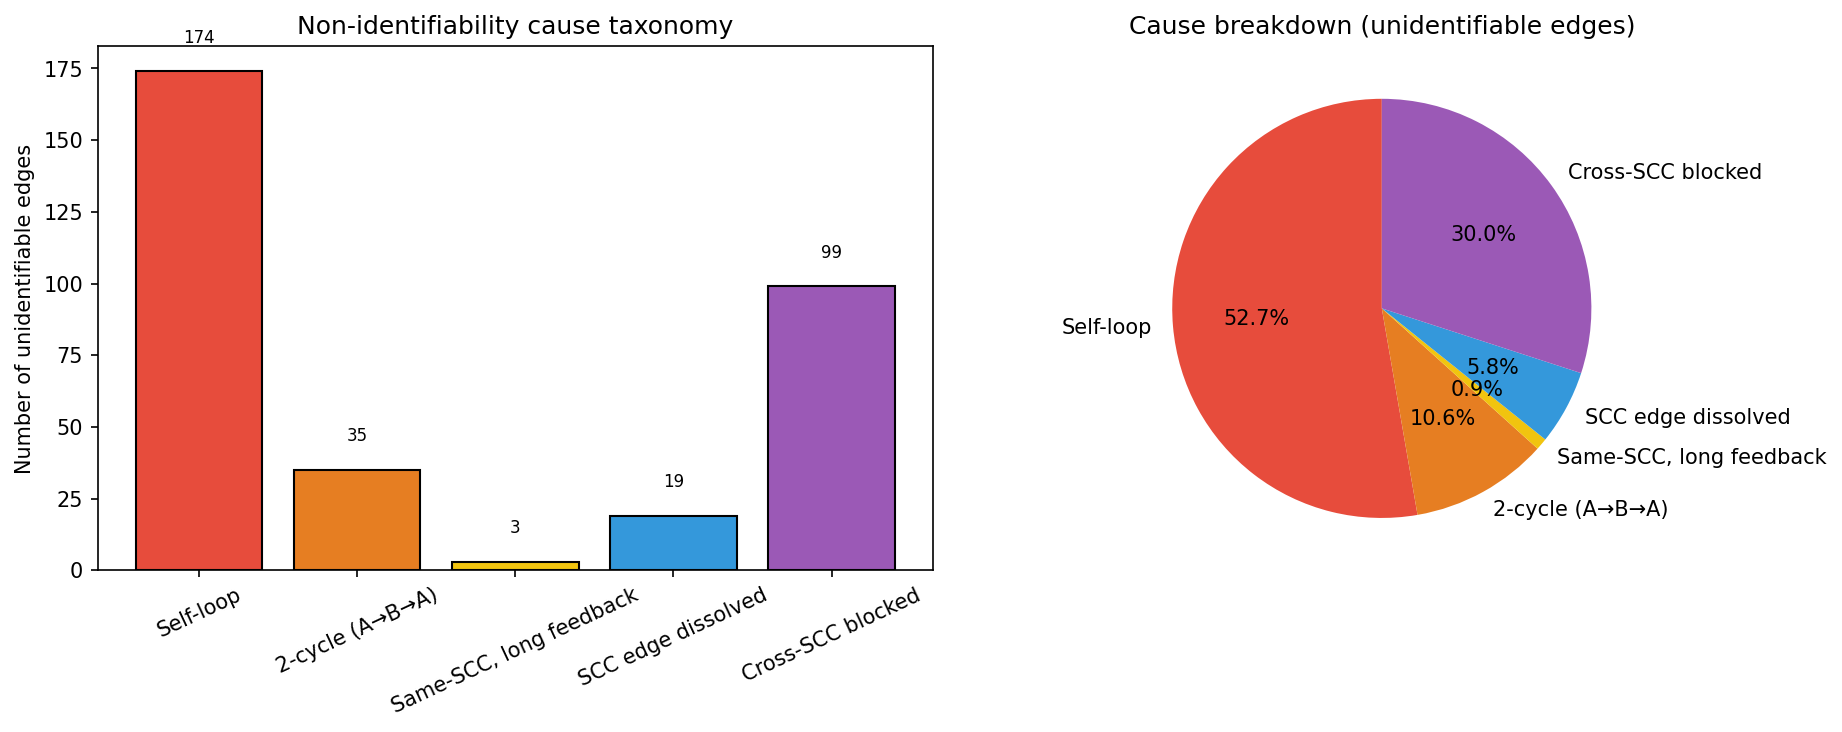

In [11]:
CATEGORY_COLORS = {
    "self_loop": "#e74c3c",
    "two_cycle": "#e67e22",
    "same_scc_long": "#f1c40f",
    "scc_edge_dissolved": "#3498db",
    "cross_scc_blocked": "#9b59b6",
    "unknown": "#95a5a6",
}
CATEGORY_LABELS = {
    "self_loop": "Self-loop",
    "two_cycle": "2-cycle (A→B→A)",
    "same_scc_long": "Same-SCC, long feedback",
    "scc_edge_dissolved": "SCC edge dissolved",
    "cross_scc_blocked": "Cross-SCC blocked",
}

ordered = [c for c in CAUSE_CATEGORIES if c in cause_counts.index]
vals = [cause_counts.get(c, 0) for c in ordered]
clrs = [CATEGORY_COLORS.get(c, "#95a5a6") for c in ordered]
labs = [CATEGORY_LABELS.get(c, c) for c in ordered]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(labs, vals, color=clrs, edgecolor="black")
axes[0].set_ylabel("Number of unidentifiable edges")
axes[0].set_title("Non-identifiability cause taxonomy")
axes[0].tick_params(axis="x", rotation=25)
for i, v in enumerate(vals):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=8)

# Pie chart
axes[1].pie(vals, labels=labs, colors=clrs, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Cause breakdown (unidentifiable edges)")

plt.tight_layout()
out = VIZ_DIR / "csd_nonident_causes.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
Image(out)

## 6. Intervention rescue (notebook-light)

### 6a. Per-edge targeted rescue (sampled)
For a small sample of unidentifiable edges, test each candidate intervention node
(from the SCC min-cut pool) and record which ones flip the edge to identifiable.

In [12]:
import random
from csd_rescue_worker import compute_rescue_nodes, _candidate_pool

random.seed(42)
SAMPLE_SIZE = 50  # keep fast; increase if you have time

# Filter to same-SCC unidentifiable edges (most interesting for rescue)
same_scc_unident = unident[unident.cause.map(lambda c: True)].copy()
# Use nonident_cause != self_loop (self-loops can't be rescued by do on other nodes)
rescuable_pool = unident[unident.nonident_cause != "self_loop"]
sample_edges = rescuable_pool.sample(min(SAMPLE_SIZE, len(rescuable_pool)), random_state=42)

print(f"Computing rescue nodes for {len(sample_edges)} sampled edges...")
candidates = _candidate_pool(g)
print(f"Candidate pool size: {len(candidates)} nodes")

rescue_records = []
for _, row in sample_edges.iterrows():
    if not g.has_edge(row.cause, row.effect):
        continue
    nodes = compute_rescue_nodes(g, row.cause, row.effect, candidates)
    rescue_records.append({
        "cause": row.cause,
        "effect": row.effect,
        "nonident_cause": row.nonident_cause,
        "rescue_nodes": nodes,
        "n_rescue_nodes": len(nodes),
    })

rescue_df = pd.DataFrame(rescue_records)
print(f"\n{rescue_df['n_rescue_nodes'].describe().to_string()}")
print(f"\nEdges with at least one rescue node: {(rescue_df.n_rescue_nodes > 0).sum()} / {len(rescue_df)}")

Computing rescue nodes for 50 sampled edges...
Candidate pool size: 63 nodes

count    50.000000
mean      0.460000
std       0.613122
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       3.000000

Edges with at least one rescue node: 21 / 50


Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_rescue_targets.png


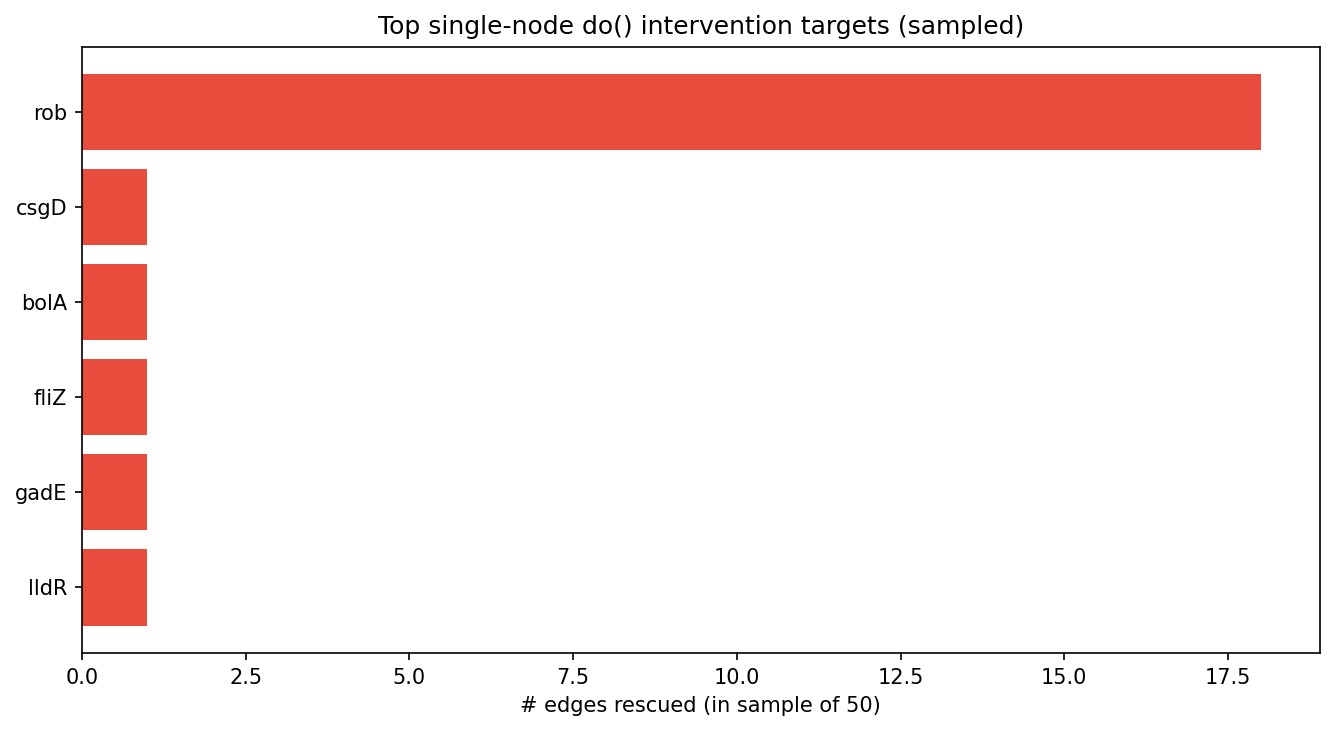

In [13]:
# Most frequently effective intervention targets (in sample)
rescue_node_counter: Counter = Counter()
for nodes in rescue_df["rescue_nodes"]:
    rescue_node_counter.update(nodes)

top_rescue = rescue_node_counter.most_common(20)
if top_rescue:
    names, cnts = zip(*top_rescue)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(list(names)[::-1], list(cnts)[::-1], color="#e74c3c")
    ax.set_xlabel(f"# edges rescued (in sample of {len(rescue_df)})")
    ax.set_title("Top single-node do() intervention targets (sampled)")
    plt.tight_layout()
    out = VIZ_DIR / "csd_rescue_targets.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
    display(Image(out))
else:
    print("No rescue nodes found in sample.")

### 6b. Global greedy intervention curve

In [ ]:
K_MAX = 5  # budget; keep small for notebook speed

print(f"Running maximize_identifiable_edges(graph, k={K_MAX})...")
print("(This may take several minutes on the full 9k-edge graph)")

greedy = maximize_identifiable_edges(g, K_MAX)

print(f"\nBaseline identifiable: {greedy['n_identifiable_baseline']:,}")
print(f"Final identifiable:    {greedy['n_identifiable_final']:,}")
print(f"Chosen interventions:  {greedy['chosen_nodes']}")
print(f"Curve: {greedy['curve']}")

Running maximize_identifiable_edges(graph, k=5)...
(This may take several minutes on the full 9k-edge graph)


In [ ]:
curve = greedy["curve"]
xs = [c[0] for c in curve]
ys = [c[1] for c in curve]
pcts = [100.0 * y / len(df) for y in ys]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, pcts, "o-", color="#2ecc71", linewidth=2, markersize=8)
ax.set_xlabel("Number of hard interventions do(v)")
ax.set_ylabel("% edges identifiable")
ax.set_title("Global greedy intervention curve\n(sigma-single-door, E. coli network)")
ax.set_ylim(0, 100)
for x, y, p in zip(xs, ys, pcts):
    ax.annotate(f"{p:.1f}%", (x, p), textcoords="offset points", xytext=(5, 3), fontsize=8)

# Annotate chosen nodes
chosen = greedy["chosen_nodes"]
for i, node in enumerate(chosen, 1):
    ax.annotate(f"do({node})", (i, pcts[i]), textcoords="offset points", xytext=(5, -12), fontsize=7, color="darkblue")

plt.tight_layout()
out = VIZ_DIR / "csd_rescue_curve.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
display(Image(out))

## 7. Full-sweep rescue results (SLURM)

If the full rescue sweep has been run on the cluster, this section loads
`csd_rescue_results.csv` and visualizes the most effective intervention targets
across *all* unidentifiable edges.

To run the full sweep:
```bash
bash scripts/slurm/submit_csd_rescue.sh
# After completion:
uv run python scripts/csd_rescue_gather.py \
    --input-dir results/cyclic_single_door/rescue_classified \
    --output-csv notebooks/Ecoli_Analysis_Notebooks/csd_rescue_results.csv \
    --output-summary notebooks/Ecoli_Analysis_Notebooks/csd_rescue_summary.json
```

In [ ]:
RESCUE_CSV = NB_DIR / "csd_rescue_results.csv"
RESCUE_SUMMARY = NB_DIR / "csd_rescue_summary.json"

if RESCUE_CSV.exists():
    rescue_full = pd.read_csv(RESCUE_CSV)
    with open(RESCUE_SUMMARY) as f:
        rescue_summary = json.load(f)

    print(f"Full sweep: {len(rescue_full):,} unidentifiable edges analysed")
    print(f"Rescuable: {rescue_summary['n_rescuable']:,} ({rescue_summary['pct_rescuable']}%)")
    print(f"\nCause counts: {rescue_summary['cause_counts']}")
    print(f"\nTop rescue nodes:")
    for row in rescue_summary["top_rescue_nodes"][:10]:
        print(f"  {row['node']}: {row['count']} edges")

    # Full-sweep top rescue targets bar chart
    top_nodes_full = rescue_summary["top_rescue_nodes"][:20]
    if top_nodes_full:
        names_f, cnts_f = zip(*[(r["node"], r["count"]) for r in top_nodes_full])
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(list(names_f)[::-1], list(cnts_f)[::-1], color="#c0392b")
        ax.set_xlabel("# unidentifiable edges rescued (full sweep)")
        ax.set_title("Top single-node do() intervention targets\n(all unidentifiable edges)")
        plt.tight_layout()
        out = VIZ_DIR / "csd_rescue_targets_full.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out}")
        display(Image(out))

    # Full cause taxonomy breakdown
    cause_counts_full = rescue_summary["cause_counts"]
    ordered_f = [c for c in CAUSE_CATEGORIES if c in cause_counts_full]
    vals_f = [cause_counts_full.get(c, 0) for c in ordered_f]
    labs_f = [CATEGORY_LABELS.get(c, c) for c in ordered_f]
    clrs_f = [CATEGORY_COLORS.get(c, "#95a5a6") for c in ordered_f]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(labs_f, vals_f, color=clrs_f, edgecolor="black")
    ax.set_ylabel("Count")
    ax.set_title("Non-identifiability cause taxonomy (full sweep)")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    out = VIZ_DIR / "csd_nonident_causes_full.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
    display(Image(out))
else:
    print("Full rescue sweep not yet available.")
    print("Run: bash scripts/slurm/submit_csd_rescue.sh")

## 8. Export final tables

In [ ]:
# Export identifiable edges
ident_out = df[df.status == "identifiable"][["cause", "effect", "adjustment_set", "same_scc"]]
ident_out.to_csv(NB_DIR / "csd_identifiable_edges.csv", index=False)
print(f"Identifiable edges: {len(ident_out):,} -> csd_identifiable_edges.csv")

# Export non-identifiability diagnosis (if computed above)
diag_path = NB_DIR / "csd_nonident_diagnosis.csv"
if diag_path.exists():
    print(f"Non-identifiability diagnosis: {diag_path}")

print("\nAll done.")